<center>
    <img src="https://skillzam.com/uploads/system/b2e34d0eb157c2b6bfd40d9c1df21c36.png" width="300" alt="cognitiveclass.ai logo"  />
</center>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing\_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


***


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [1]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis


First, let's read the SpaceX dataset "dataset_part_2.csv" into a Pandas dataframe and print its summary






In [2]:
df=pd.read_csv("/content/dataset_part_2 (1).csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90 non-null     object 
 6   Outcome         90 non-null     object 
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      90 non-null     object 
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     object 
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
 17  landing_class   90 non-null     int64

In [4]:
df.describe()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Longitude,Latitude,landing_class
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,45.500000,6123.547647,1.788889,3.500000,3.188889,-86.366477,29.449963,0.666667
std,26.124701,4732.115291,1.213172,1.595288,4.194417,14.149518,2.141306,0.474045
min,1.000000,350.000000,1.000000,1.000000,0.000000,-120.610829,28.561857,0.000000
25%,23.250000,2510.750000,1.000000,2.000000,0.000000,-80.603956,28.561857,0.000000
50%,45.500000,4701.500000,1.000000,4.000000,1.000000,-80.577366,28.561857,1.000000
75%,67.750000,8912.750000,2.000000,5.000000,4.000000,-80.577366,28.608058,1.000000
max,90.000000,15600.000000,6.000000,5.000000,13.000000,-80.577366,34.632093,1.000000


In [5]:
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,landing_class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B1004,-80.577366,28.561857,0


In [6]:
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,landing_class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


Text(0, 0.5, 'PayloadMass')

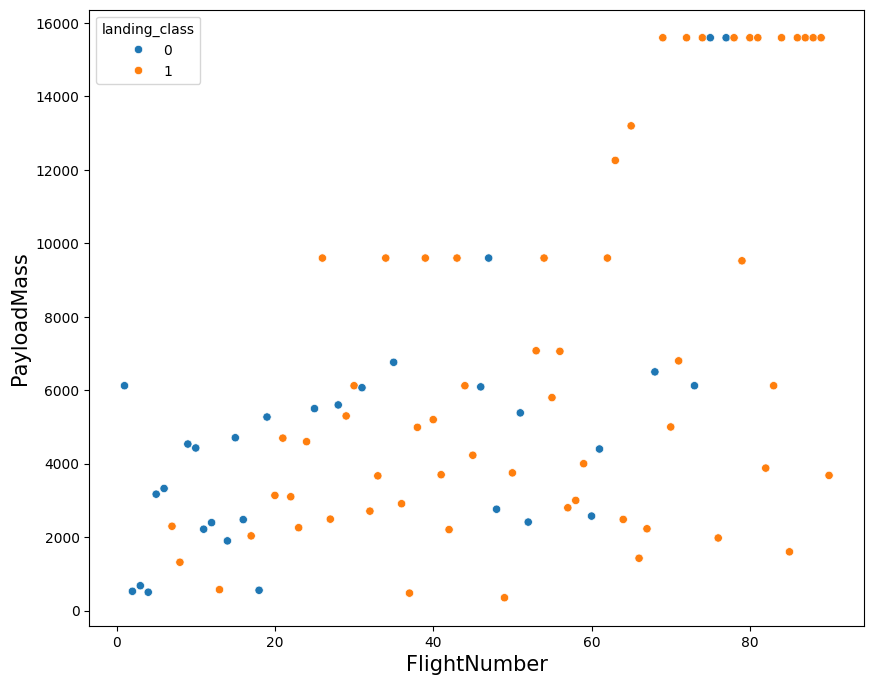

In [7]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x="FlightNumber",y="PayloadMass",hue="landing_class")
plt.xlabel("FlightNumber",fontsize=15)
plt.ylabel("PayloadMass",fontsize=15)

We see that different launch sites have different success rates.  <code>CCAFS LC-40</code>, has a success rate of 60 %, while  <code>KSC LC-39A</code> and <code>VAFB SLC 4E</code> has a success rate of 77%.


In [8]:
success_rate_by_launchsite = df.groupby('LaunchSite')['landing_class'].mean().reset_index()
print("Success rate by Launch Site:")
display(success_rate_by_launchsite)

Success rate by Launch Site:


,LaunchSite,landing_class
0,CCSFS SLC 40,0.600000
1,KSC LC 39A,0.772727
2,VAFB SLC 4E,0.769231


/tmp/ipython-input-536621931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=success_rate_by_launchsite, x='LaunchSite', y='landing_class', palette='viridis')


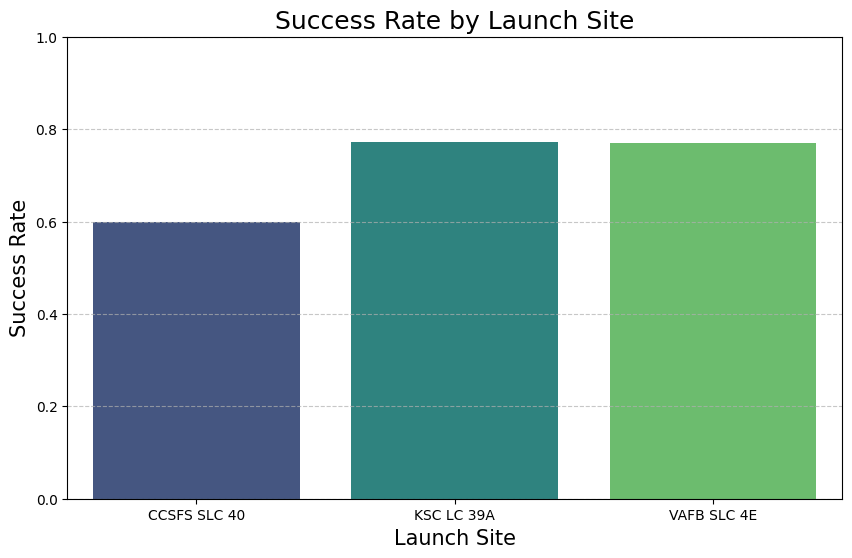

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(data=success_rate_by_launchsite, x='LaunchSite', y='landing_class', palette='viridis')
plt.xlabel('Launch Site', fontsize=15)
plt.ylabel('Success Rate', fontsize=15)
plt.title('Success Rate by Launch Site', fontsize=18)
plt.ylim(0, 1) # Success rate is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


Text(58.46922839506176, 0.5, 'LaunchSite')

<Figure size 1000x800 with 0 Axes>

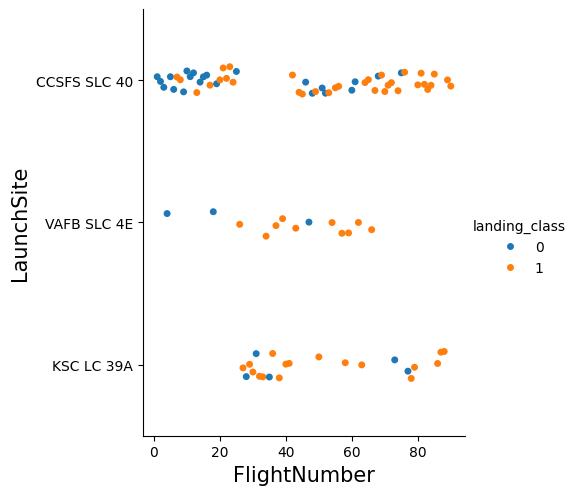

In [10]:
plt.figure(figsize=(10,8))
sns.catplot(data=df,x="FlightNumber",y="LaunchSite",hue="landing_class")
plt.xlabel("FlightNumber",fontsize=15)
plt.ylabel("LaunchSite",fontsize=15)

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


Text(0, 0.5, 'PayloadMass')

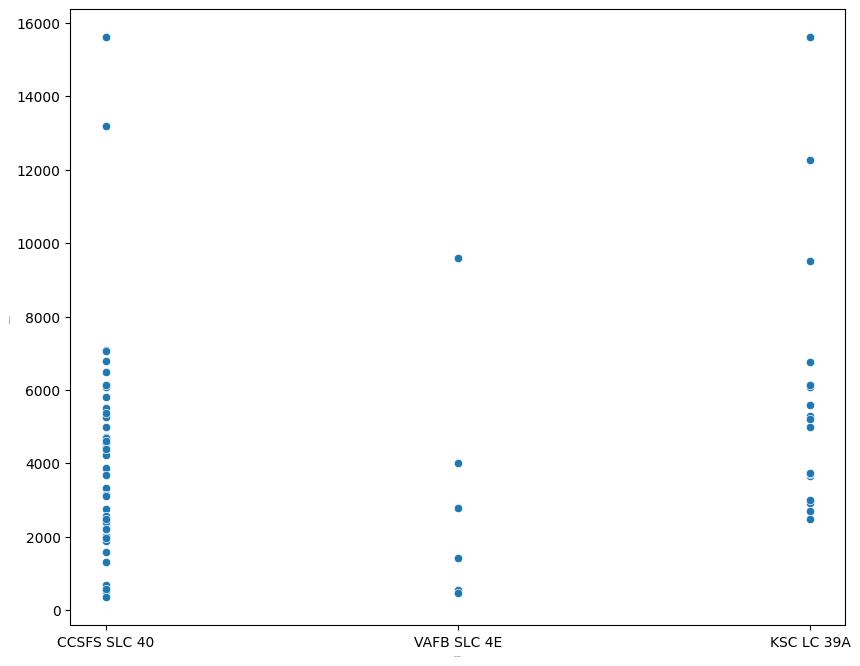

In [11]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x="LaunchSite",y="PayloadMass")
plt.xlabel("LaunchSite",fontsize=1)
plt.ylabel("PayloadMass",fontsize=1)

Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


Text(0, 0.5, 'landing_class')

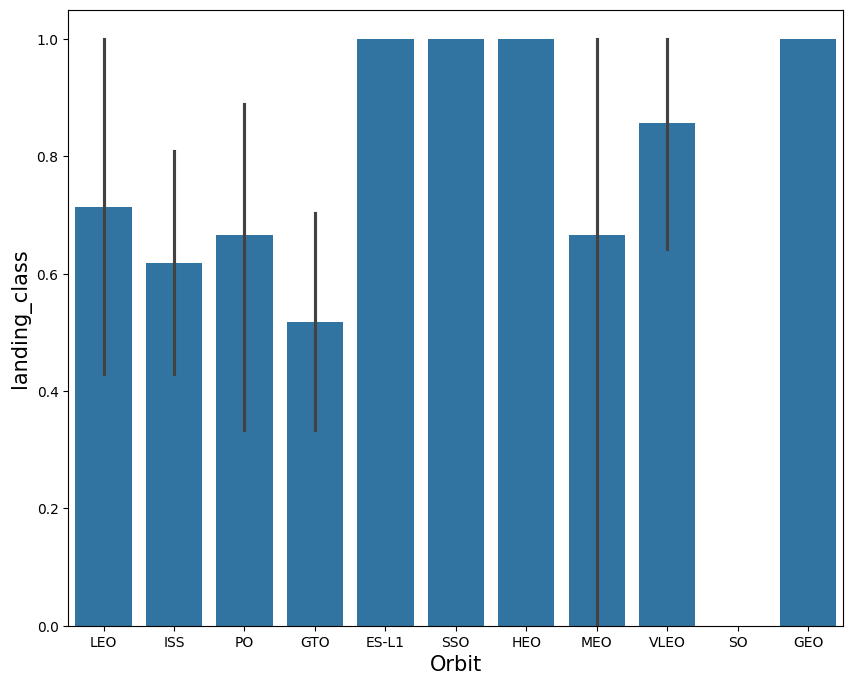

In [12]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x="Orbit",y="landing_class")
plt.xlabel("Orbit",fontsize=15)
plt.ylabel("landing_class",fontsize=15)


Analyze the ploted bar chart try to find which orbits have high sucess rate.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


Text(0, 0.5, 'Orbit')

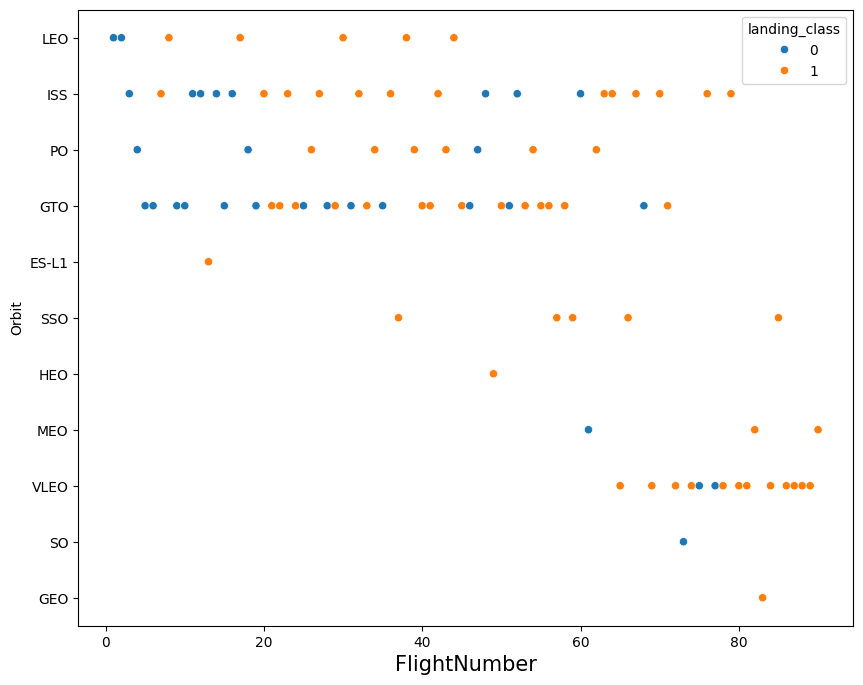

In [13]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x="FlightNumber",y="Orbit",hue="landing_class")
plt.xlabel("FlightNumber",fontsize=15)
plt.ylabel("Orbit")

You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


Text(0, 0.5, 'Orbit')

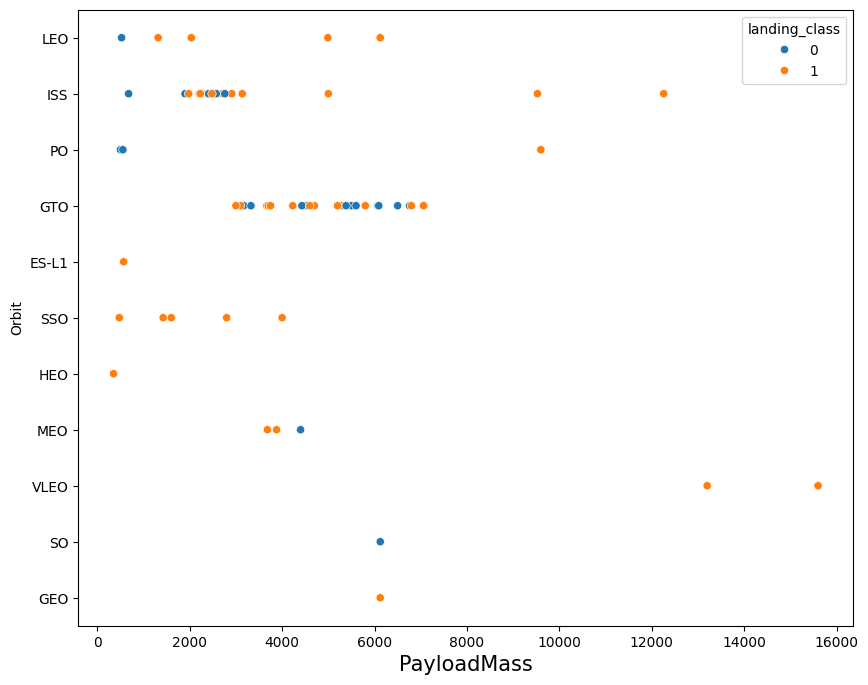

In [14]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x="PayloadMass",y="Orbit",hue="landing_class")
plt.xlabel("PayloadMass",fontsize=15)
plt.ylabel("Orbit")

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.


### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


The function will help you get the year from the date:


In [15]:
df.columns

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'landing_class'],
      dtype='object')

In [16]:
df["year"]=pd.to_datetime(df["Date"]).dt.year

<Axes: xlabel='year', ylabel='landing_class'>

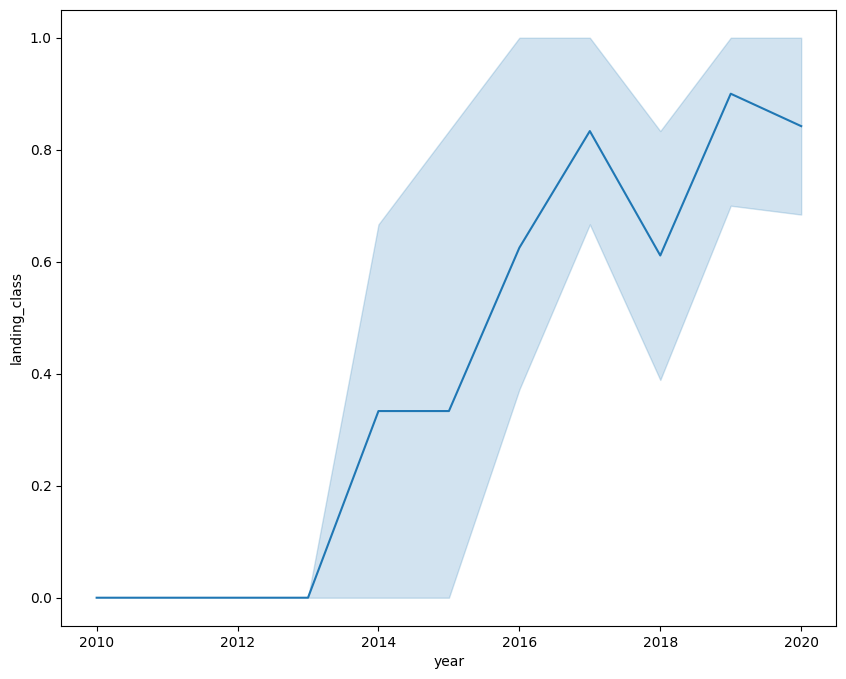

In [17]:
plt.figure(figsize=(10,8))
sns.lineplot(data=df,x="year",y="landing_class")

Text(0, 0.5, 'Landing_class')

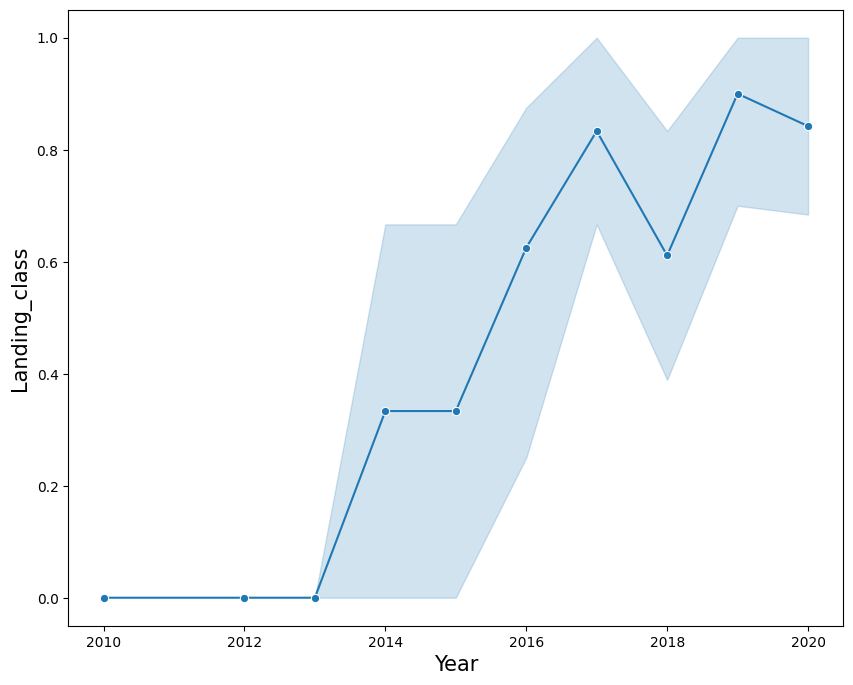

In [18]:
plt.figure(figsize=(10,8))
sns.lineplot(data=df, x="year", y="landing_class", marker="o")
plt.xlabel("Year",fontsize=15)
plt.ylabel("Landing_class",fontsize=15)

you can observe that the sucess rate since 2013 kept increasing till 2020


## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [19]:
features = ['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Block', 'Serial', 'Flights', 'LandingPad']
target = 'landing_class'
x=df[features]
y=df[target]

In [20]:
df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Block', 'Serial', 'Flights', 'LandingPad']]

,FlightNumber,PayloadMass,Orbit,LaunchSite,Block,Serial,Flights,LandingPad
0,1,6123.547647,LEO,CCSFS SLC 40,1.0,B0003,1,5e9e3032383ecb6bb234e7ca
1,2,525.000000,LEO,CCSFS SLC 40,1.0,B0005,1,5e9e3032383ecb6bb234e7ca
2,3,677.000000,ISS,CCSFS SLC 40,1.0,B0007,1,5e9e3032383ecb6bb234e7ca
3,4,500.000000,PO,VAFB SLC 4E,1.0,B1003,1,5e9e3032383ecb6bb234e7ca
4,5,3170.000000,GTO,CCSFS SLC 40,1.0,B1004,1,5e9e3032383ecb6bb234e7ca
...,...,...,...,...,...,...,...,...
85,86,15600.000000,VLEO,KSC LC 39A,5.0,B1060,2,5e9e3032383ecb6bb234e7ca
86,87,15600.000000,VLEO,KSC LC 39A,5.0,B1058,3,5e9e3032383ecb6bb234e7ca
87,88,15600.000000,VLEO,KSC LC 39A,5.0,B1051,6,5e9e3032383ecb6bb234e7ca
88,89,15600.000000,VLEO,CCSFS SLC 40,5.0,B1060,3,5e9e3033383ecbb9e534e7cc


### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [21]:
features_one_hot = pd.get_dummies(
    x,
    columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial']
)

# Display the first few rows
features_one_hot.head()

features_one_hot = features_one_hot.astype(int)
features_one_hot.head()


,FlightNumber,PayloadMass,Block,Flights,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6123,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2,525,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,677,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,4,500,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,3170,1,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
features_one_hot.dtypes

,0
FlightNumber,int64
PayloadMass,int64
Block,int64
Flights,int64
Orbit_ES-L1,int64
...,...
Serial_B1056,int64
Serial_B1058,int64
Serial_B1059,int64
Serial_B1060,int64


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [23]:

features_one_hot = features_one_hot.astype('float64')

features_one_hot.head()


,FlightNumber,PayloadMass,Block,Flights,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6123.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
features_one_hot.dtypes

,0
FlightNumber,float64
PayloadMass,float64
Block,float64
Flights,float64
Orbit_ES-L1,float64
...,...
Serial_B1056,float64
Serial_B1058,float64
Serial_B1059,float64
Serial_B1060,float64


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


In [25]:
X = features_one_hot
y = df['landing_class']


In [26]:
final_df = pd.concat([features_one_hot, y], axis=1)
final_df.to_csv('dataset_part_31_with_target.csv', index=False)
final_df.head()


,FlightNumber,PayloadMass,Block,Flights,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,...,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,landing_class
0,1.0,6123.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2.0,525.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3.0,677.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,4.0,500.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5.0,3170.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [27]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

# Task
Perform feature engineering by applying one-hot encoding to the 'Orbit', 'LaunchSite', 'LandingPad', and 'Serial' columns of the `features` dataframe using `pd.get_dummies`, storing the result in `features_one_hot`, and then casting all columns in `features_one_hot` to the `float64` data type.

## Create Dummy Variables

### Subtask:
Apply one-hot encoding using `pd.get_dummies` to the categorical columns 'Orbit', 'LaunchSite', 'LandingPad', and 'Serial' from the dataframe created by selecting the `features`. Assign the result to `features_one_hot` and display its head.


## Cast to Float64

### Subtask:
Convert all numeric columns in the `features_one_hot` dataframe to the `float64` data type to ensure consistency and compatibility for future modeling.


**Reasoning**:
Convert all columns in the `features_one_hot` DataFrame to `float64` and display the first five rows to verify the conversion.



In [28]:
features_one_hot = features_one_hot.astype(float)
features_one_hot.head()

,FlightNumber,PayloadMass,Block,Flights,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6123.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Final Task

### Subtask:
Summarize the feature engineering steps performed and confirm the readiness of the data for the next phase of success prediction.


## Summary:

### Q&A
1.  **What feature engineering steps were performed?**
    One-hot encoding was applied to the categorical columns 'Orbit', 'LaunchSite', 'LandingPad', and 'Serial' using `pd.get_dummies`. Subsequently, all columns in the resulting `features_one_hot` dataframe were cast to the `float64` data type.
2.  **Is the data ready for the next phase of success prediction?**
    Yes, the data is ready. The categorical features have been successfully transformed into a numerical format suitable for machine learning models, and all features are cast to a consistent `float64` data type.

### Data Analysis Key Findings
*   One-hot encoding was successfully applied to the specified categorical columns ('Orbit', 'LaunchSite', 'LandingPad', 'Serial'), converting them into a numerical representation.
*   All columns in the `features_one_hot` dataframe were successfully converted to the `float64` data type, ensuring data type consistency for subsequent modeling.

### Insights or Next Steps
*   The data has been appropriately preprocessed with one-hot encoding and standardized data types, making it suitable for direct input into machine learning models for success prediction.
*   The next logical step is to split the data into training and testing sets, and then proceed with model selection and training using the `features_one_hot` dataframe and the `Y` target variable.

## Summary:

### Q&A
1.  **What feature engineering steps were performed?**
    One-hot encoding was applied to the categorical columns 'Orbit', 'LaunchSite', 'LandingPad', and 'Serial' using `pd.get_dummies`. Subsequently, all columns in the resulting `features_one_hot` dataframe were cast to the `float64` data type.
2.  **Is the data ready for the next phase of success prediction?**
    Yes, the data is ready. The categorical features have been successfully transformed into a numerical format suitable for machine learning models, and all features are cast to a consistent `float64` data type.

### Data Analysis Key Findings
*   One-hot encoding was successfully applied to the specified categorical columns ('Orbit', 'LaunchSite', 'LandingPad', 'Serial'), converting them into a numerical representation.
*   All columns in the `features_one_hot` dataframe were successfully converted to the `float64` data type, ensuring data type consistency for subsequent modeling.

### Insights or Next Steps
*   The data has been appropriately preprocessed with one-hot encoding and standardized data types, making it suitable for direct input into machine learning models for success prediction.
*   The next logical step is to split the data into training and testing sets, and then proceed with model selection and training using the `features_one_hot` dataframe and the `Y` target variable.
